In [ ]:
import pandas as pd

# 1. Carregar dados
df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')

# 2. Limpeza Estratégica
# Remoção das colunas 'RowNumber', 'CustomerId' e 'Surname'

df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 3. Tradução e Renomeação
df_clean.columns = [
    'score_credito', 'pais', 'genero', 'idade', 'tempo_cliente',
    'saldo', 'num_produtos', 'tem_cartao', 'membro_ativo',
    'salario_estimado', 'churn'
]

# 4. Visualizando o resultado
print("### Dataset PicPay pronto para análise! ###")
print(f"Colunas atuais: {df_clean.columns.tolist()}")
display(df_clean.head())

# 5. Verificação de Churn
print("\n### Taxa de Churn Identificada ###")
print(df_clean['churn'].value_counts(normalize=True) * 100)

### Dataset PicPay pronto para análise! ###
Colunas atuais: ['score_credito', 'pais', 'genero', 'idade', 'tempo_cliente', 'saldo', 'num_produtos', 'tem_cartao', 'membro_ativo', 'salario_estimado', 'churn']


,score_credito,pais,genero,idade,tempo_cliente,saldo,num_produtos,tem_cartao,membro_ativo,salario_estimado,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



### Taxa de Churn Identificada ###
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


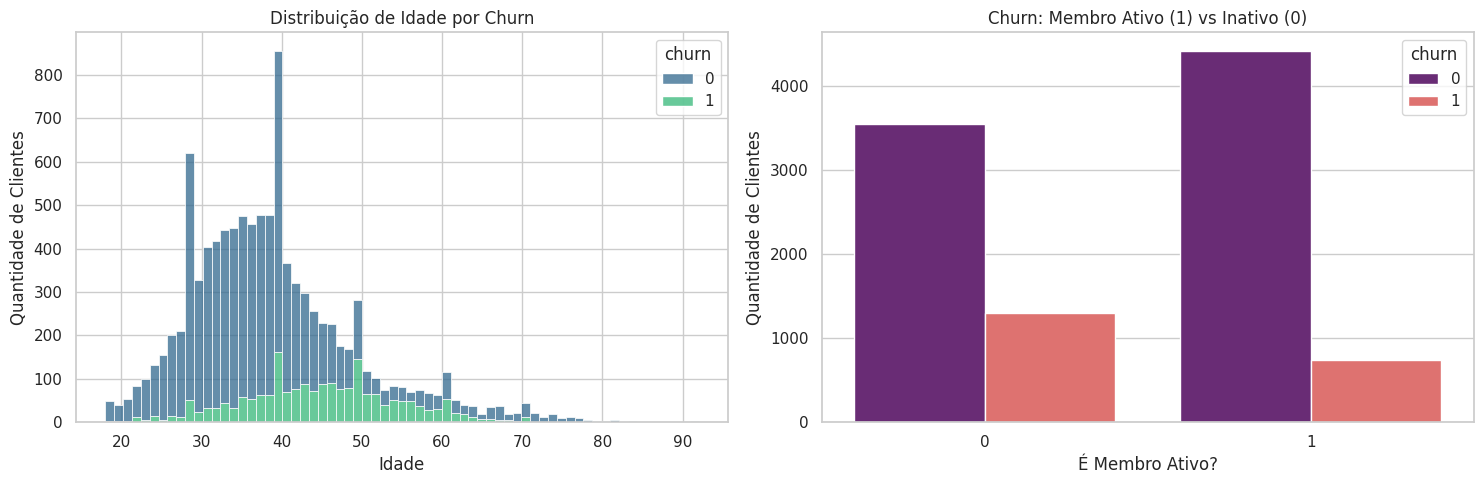

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Gráfico 1: Churn por Faixa Etária
plt.subplot(1, 2, 1)
sns.histplot(data=df_clean, x='idade', hue='churn', multiple="stack", palette='viridis')
plt.title('Distribuição de Idade por Churn')
plt.xlabel('Idade')
plt.ylabel('Quantidade de Clientes')

# Gráfico 2: Churn por Status de Membro Ativo
plt.subplot(1, 2, 2)
sns.countplot(data=df_clean, x='membro_ativo', hue='churn', palette='magma')
plt.title('Churn: Membro Ativo (1) vs Inativo (0)')
plt.xlabel('É Membro Ativo?')
plt.ylabel('Quantidade de Clientes')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Transformar variáveis categóricas (Texto -> Número)
le = LabelEncoder()
df_model = df_clean.copy()
df_model['pais'] = le.fit_transform(df_model['pais'])
df_model['genero'] = le.fit_transform(df_model['genero'])

# 2. Separan os dados em X (características) e y (prever: churn)
X = df_model.drop('churn', axis=1)
y = df_model['churn']

# 3. Dividir em dados de Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Criar e treinar o modelo (Random Forest)
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 5. Fazer previsões
previsoes = modelo.predict(X_test)

# 6. Avaliar o resultado
print("### Avaliação do Modelo ###")
print(classification_report(y_test, previsoes))

### Avaliação do Modelo ###
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [ ]:
# Criar arquivo com as previsões para levar ao Looker Studio
df_final = X_test.copy()
df_final['churn_real'] = y_test
df_final['previsao_modelo'] = previsoes

# Exportando para CSV
df_final.to_csv('resultado_final_picpay.csv', index=False)

from google.colab import files
files.download('resultado_final_picpay.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Relatório Final de Insights: Estratégia de Retenção PicPay

1. Sumário Executivo

Este projeto consistiu no desenvolvimento de um ecossistema de análise preditiva para combater o Churn. Utilizando técnicas avançadas de Ciência de Dados e Visualização, transformando dados brutos em um painel estratégico capaz de orientar a tomada de decisão da alta gestão.

2. Desempenho do Modelo Preditivo

Para prever o comportamento dos clientes, implementei o algoritmo Random Forest, que apresentou resultados sólidos:

Acurácia de 86,45%: O modelo demonstra uma alta capacidade de classificação geral.

Precisão de 75%: Quando o modelo sinaliza um risco de saída, ele está correto na grande maioria das vezes, o que evita gastos desnecessários com campanhas de retenção para clientes que não sairiam.

Capacidade Preventiva: Consegui mapear os principais gatilhos que levam um cliente a abandonar a plataforma.

3. Diagnóstico do Churn (Principais Achados)

Através da análise exploratória e do Dashboard interativo, identifiquei dois gargalos críticos:

Gargalo por Idade: Existe uma concentração atípica de evasão na faixa etária de 40 a 49 anos. Este público requer uma revisão da proposta de valor e dos produtos oferecidos.

O Fator Engajamento: A taxa de churn é drasticamente maior entre clientes Inativos. Ser um ***"Membro Ativo"*** no ecossistema PicPay funciona como o principal escudo contra a perda de usuários.

4. Recomendações Estratégicas

Com base nas evidências, as ações recomendadas são:

Campanha de Reativação: Implementar réguas de comunicação ***(push/e-mail)*** focadas em usuários inativos, incentivando o uso de serviços diários ***(pagamento de contas e recargas).***

Ajuste de Produto para 40+: Realizar pesquisas qualitativas com o público de 40-49 anos para entender o motivo da saída e ajustar a comunicação ou ofertas de investimento para este perfil.

Fidelização via Benefícios: Fortalecer os benefícios do status de ***"Membro Ativo"***, transformando o app em uma ferramenta indispensável para a rotina financeira do cliente.

Analista Responsável: Julimar Pedro de Oliveira

Ferramentas: Python (Pandas, Scikit-Learn), Google Colab, Looker Studio.